# MNIST 손글씨 숫자 분류를 CNN(Convolution) 방식으로 학습

Train data: (60000, 28, 28)
Train label: (60000,)
Test data: (10000, 28, 28)
Test label: (10000,)
After reshape train: (60000, 28, 28, 1)
After reshape test: (10000, 28, 28, 1)


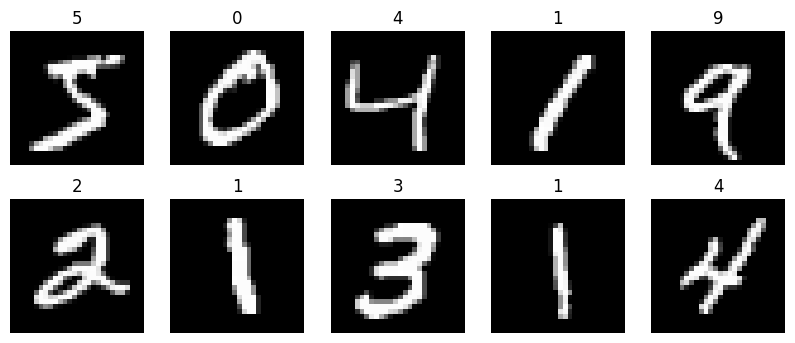

/Users/ganghyejun/Desktop/100_College/2-1/인공지능개론/AICLASS_2-1/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9412 - loss: 0.1924 - val_accuracy: 0.9783 - val_loss: 0.0742
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9816 - loss: 0.0579 - val_accuracy: 0.9845 - val_loss: 0.0535
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9870 - loss: 0.0408 - val_accuracy: 0.9865 - val_loss: 0.0447
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9904 - loss: 0.0300 - val_accuracy: 0.9891 - val_loss: 0.0421
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9923 - loss: 0.0238 - val_accuracy: 0.9895 - val_loss: 0.0405
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9892 - loss: 0.0328
Test Loss: 0.03279094025492668
Test Accuracy: 0.9891999959945679
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


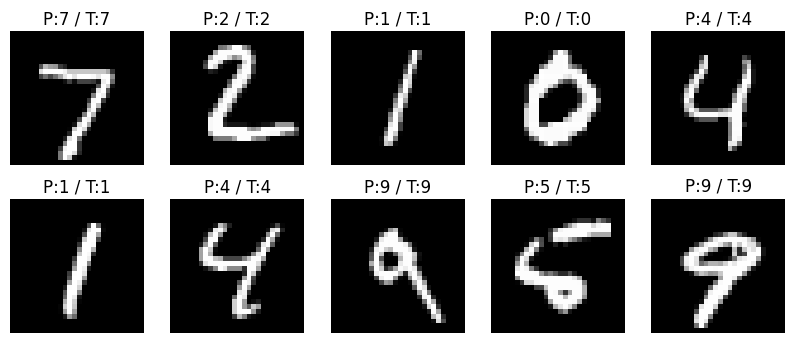

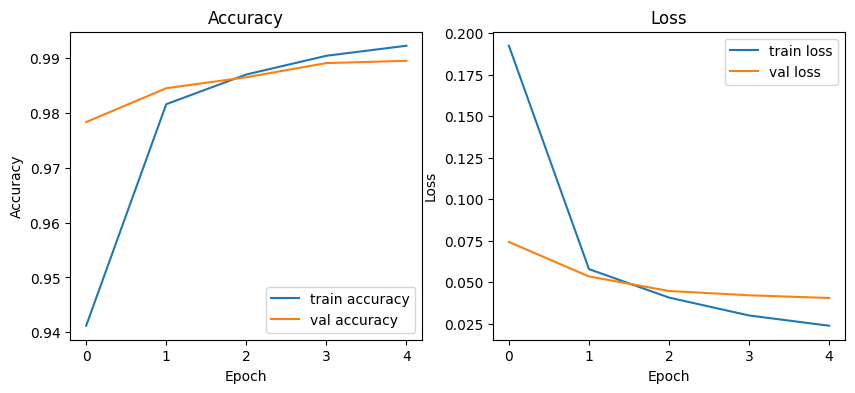

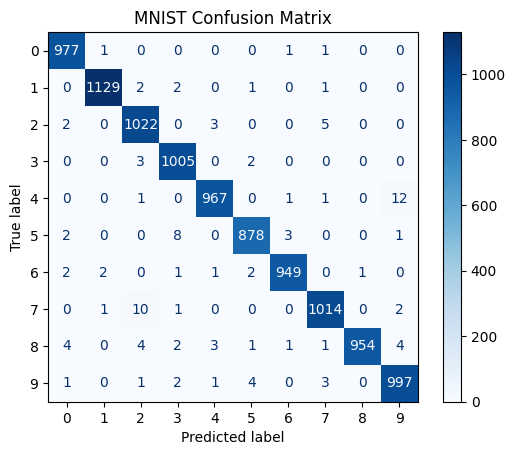

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# 1. MNIST 데이터 로드
# =========================

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Train data:", x_train.shape)
print("Train label:", y_train.shape)
print("Test data:", x_test.shape)
print("Test label:", y_test.shape)

# =========================
# 2. 정규화
# =========================

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# =========================
# 3. reshape
# CNN은 (height, width, channel) 형태 필요
# MNIST는 흑백 이미지라 channel = 1
# =========================

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("After reshape train:", x_train.shape)
print("After reshape test:", x_test.shape)

# =========================
# 4. 데이터 확인
# =========================

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")

plt.show()

# =========================
# 5. CNN 모델 구성
# =========================

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

# =========================
# 6. compile
# =========================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# 7. fit
# =========================

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# =========================
# 8. evaluate
# =========================

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

# =========================
# 9. predict
# =========================

predictions = model.predict(x_test)

pred_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")

    plt.title(f"P:{pred_labels[i]} / T:{y_test[i]}")
    plt.axis("off")

plt.show()

# =========================
# 10. Accuracy / Loss 그래프
# =========================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# =========================
# 11. Confusion Matrix
# =========================

cm = confusion_matrix(y_test, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("MNIST Confusion Matrix")
plt.show()